In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from itertools import combinations
import pandas as pd

#### Gera uns 15 pontos aleatórios num plano, com coordenadas entre 0 e 100. A rota passa por todas as cidades uma vez e volta pra primeira. O objetivo é a menor distância total.

#### Representação. O indivíduo é a ordem de visita, tipo [0, 4, 2, 7, ...], uma permutação das cidades. É a mesma ideia da permutação que a gente discutiu nas rainhas, só que aqui ela é obrigatória.

In [164]:
coord = []
for _ in range(15):
    (x,y) = (random.randint(0,100),random.randint(0,100))
    coord.append((x,y))
print(coord)

[(58, 35), (5, 9), (71, 57), (27, 4), (35, 62), (8, 50), (32, 91), (65, 30), (59, 44), (56, 35), (11, 53), (14, 98), (76, 22), (25, 8), (67, 25)]


In [3]:
def distancia(lista_coord):
    c1 = np.array(lista_coord[0])
    c2 = np.array(lista_coord[1])
    dist = np.linalg.norm(c2-c1)
    return dist

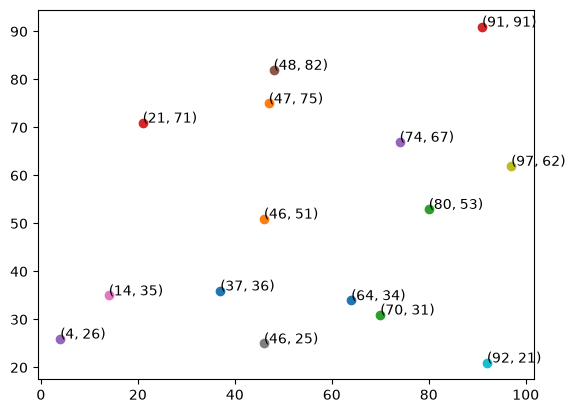

In [56]:
for c in coord:
    plt.scatter(c[0],c[1])
    plt.text(c[0],c[1],f"{c[0],c[1]}")

#### Função objetivo. Soma das distâncias entre cidades consecutivas, mais o trecho de volta pra primeira.

In [4]:
def fo(pop):
    # [(37, 36), (46, 51), (70, 31), (91, 91), (74, 67), (48, 82), (14, 35), (46, 25), (97, 62), (92, 21), (64, 34), (47, 75), (80, 53), (21, 71), (4, 26)]
    # [0,1,2,3,7,6,5,8,9,10,11,...]
    
    # teste = [(37, 36), (46, 51), (70, 31), (91, 91), (74, 67)]
    teste = coord
    dc = {}
    #[3,1,0,2,4]
    for i,j in enumerate(pop):
        # print(f"i: {i} , j:{j} , {teste[i]}")
        dc[j]=teste[i]
    df = pd.Series(dc).sort_index()
    final = df.tolist()
    # print(lista_ordenada)

    j=0
    soma=0
    for i in range(len(final)):
        
        try:
            # print(f"{final[i]} -> {final[i+1]}")
            soma+= distancia([final[i],final[i+1]])
        except:
            pass
        # print(i, len(final))
        if i == len(final)-1:
            # print("Chegou ao fim")
            # print(f"{final[i]} -> {final[j]}")
            soma+=distancia([final[i],final[j]])
    return soma




In [ ]:
def ga(pop_tamanho, num_gen):

    # inicialização
    populacao = []
    fitness_historico = []
    best_solution = None
    best_fitness = float("inf")

        #  popular população
    p = [i for i in range(15)]
    for _ in range(pop_tamanho):
        pp = np.random.permutation(p).tolist()
        populacao.append(pp)

    for n_gen in range(num_gen):
        # evaluation  #separar população feasible
        feasible_pop = populacao
        # feasible_fit = [fo(p) for p in feasible_pop]
        
        # selecao  # selecao dos pais
        
        pais = []
        for _ in range(pop_tamanho):
            
            #  corte = n Random
            p0 = random.choices(populacao, k=3)
            # p1 = random.choices(populacao, k=3)
            minp0= min(p0, key = lambda p: fo(p))
            # maxp1 = min(p1, key = lambda p: fo(p))
            pais.append(minp0)


        offspring = []
        # crossover
        for i in range(len(pais)):
            n = random.randint(2,14)
            p1 = random.choice(pais)[:n]
            p3 = random.choice(pais)
            p2 = [item for item in p3 if item not in p1]
            filho = p1+p2
            offspring.append(filho)

        # mutacao
        tx = 1/4
        for fi in range(len(offspring)):
            k = random.choices(range(15),k=2)
            if random.random()<=tx:
                offspring[fi][k[0]], offspring[fi][k[1]] = offspring[fi][k[1]],offspring[fi][k[0]]
    
        # elitismo
        if best_solution is not None:
            offspring[0] = best_solution

        populacao = offspring

        feasible_solutions = populacao

        if feasible_solutions:
            best_solution = min(feasible_solutions, key= lambda p: fo(p))
            best_fitness = fo(best_solution)
            
        fitness_historico.append(best_fitness)

        print(f"Geração {n_gen+1}, Best solution: {best_solution}, Best Fitness: {best_fitness}")


    return best_solution

In [162]:
ga(550,100)

Geração 1, Best solution: [11, 3, 5, 2, 9, 0, 12, 8, 4, 14, 13, 10, 6, 7, 1], Best Fitness: 476.4687900579882
Geração 2, Best solution: [14, 2, 9, 8, 13, 3, 5, 7, 10, 0, 4, 6, 12, 11, 1], Best Fitness: 424.8534011350439
Geração 3, Best solution: [14, 2, 9, 8, 13, 3, 5, 7, 10, 0, 4, 6, 12, 11, 1], Best Fitness: 424.8534011350439
Geração 4, Best solution: [8, 3, 13, 12, 9, 5, 7, 1, 11, 6, 2, 10, 0, 14, 4], Best Fitness: 401.2370659273379
Geração 5, Best solution: [8, 3, 13, 12, 9, 5, 7, 1, 11, 6, 2, 10, 0, 14, 4], Best Fitness: 401.2370659273379
Geração 6, Best solution: [8, 3, 13, 12, 9, 5, 7, 1, 11, 6, 2, 10, 0, 14, 4], Best Fitness: 401.2370659273379
Geração 7, Best solution: [8, 3, 13, 12, 9, 5, 7, 1, 11, 6, 2, 10, 0, 14, 4], Best Fitness: 401.2370659273379
Geração 8, Best solution: [8, 3, 13, 12, 9, 5, 7, 1, 11, 6, 2, 10, 0, 14, 4], Best Fitness: 401.2370659273379
Geração 9, Best solution: [14, 2, 8, 9, 13, 6, 7, 12, 10, 3, 5, 0, 1, 11, 4], Best Fitness: 395.31733254796376
Geração 1

'ok'

In [171]:
lista_alvo = coord
resultado = [14, 2, 8, 9, 13, 1, 6, 11, 10, 4, 5, 0, 7, 12, 3]
print(lista_alvo)

[(58, 35), (5, 9), (71, 57), (27, 4), (35, 62), (8, 50), (32, 91), (65, 30), (59, 44), (56, 35), (11, 53), (14, 98), (76, 22), (25, 8), (67, 25)]


In [172]:
dc = {}
for i,j in enumerate(resultado):
    # print(f"i: {i} , j:{j} , {teste[i]}")
    dc[j]=lista_alvo[i]
df = pd.Series(dc).sort_index()
df

0     (14, 98)
1      (8, 50)
2       (5, 9)
3     (67, 25)
4     (56, 35)
5     (11, 53)
6     (32, 91)
7     (76, 22)
8     (71, 57)
9      (27, 4)
10    (59, 44)
11    (65, 30)
12     (25, 8)
13    (35, 62)
14    (58, 35)
dtype: object

(14, 98) - (8, 50)
(8, 50) - (5, 9)
(5, 9) - (67, 25)
(67, 25) - (56, 35)
(56, 35) - (11, 53)
(11, 53) - (32, 91)
(32, 91) - (76, 22)
(76, 22) - (71, 57)
(71, 57) - (27, 4)
(27, 4) - (59, 44)
(59, 44) - (65, 30)
(65, 30) - (25, 8)
(25, 8) - (35, 62)
(35, 62) - (58, 35)
(58, 35) - (14, 98)


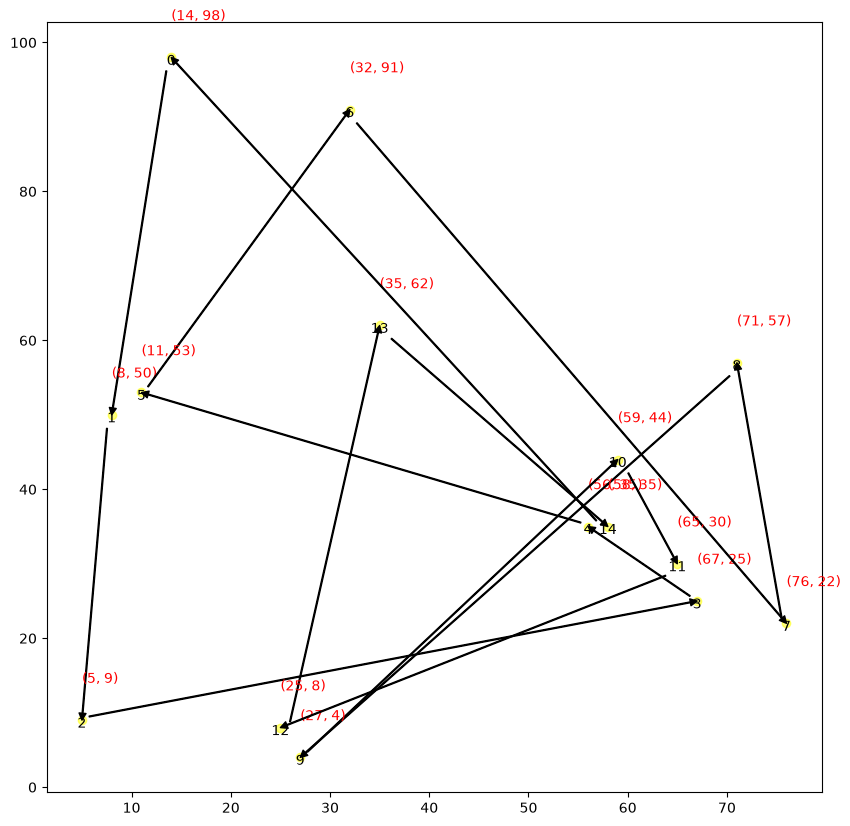

In [222]:
fig, ax = plt.subplots(figsize=(10,10))

for i in range(len(df)):
    if i == len(df)-1:
        x = df.shift(-i)[0]
        y = df[0]
        print(x,'-',y)
    else:
        x = df.shift(-i)[0]
        y = df.shift(-(i+1))[0]
        print(x,'-',y)
    plt.scatter(x[0],x[1],alpha=0.5,color='yellow')
    ax.annotate(f'{i}', xy=(y[0], y[1]), xytext=(x[0], x[1]-1),
            arrowprops=dict(facecolor='black',width=0.6,headwidth=5,headlength=5),ha='center')        
    plt.text(x[0],x[1]+5,f"{(x[0],x[1])}",color='red')